# GPSR LUME Datasets and DataModules

This notebook shows how to create a `GPSRLUMEDataset` from quad scan data, and a
`GPSRLUMEDataModule` from multiple quad scans' `GPSRLUMEDataset`. The
`GPSRLUMEDataModule` is the data structure used for training in GPSR-LUME.

In [1]:
import json
from pathlib import Path

import numpy as np
import torch

from gpsr.lume.data import GPSRLUMEDataModule, GPSRLUMEDataset
from gpsr.lume.plotting import plot_images, plot_multi_source_images

MEASUREMENTS_DIR = Path("measurements")  # raw scan data, one directory per scan
DATASETS_DIR = Path("datasets")  # what this notebook writes
DATASETS_DIR.mkdir(exist_ok=True)

## 1. Create, save and load a `GPSRLUMEDataset` corresponding to a single quad scan

A scan directory holds two arrays and a text file. The arrays are numbers; the JSON is
the only reason anyone can tell *what* those numbers are. That is what a measurement
actually leaves behind, and between them they carry everything needed to interpret this
scan alone.

A `GPSRLUMEDataset` takes four arguments, all keyed by **PV name**:

| | |
|---|---|
| `observations` | the measured arrays, `(n_samples, …)` each — here one screen's images |
| `beamline_settings` | what was *varied*, one value per step: `(n_samples,)` each |
| `observations_metadata` | how to read each observation — same keys as `observations` |
| `beamline_constants` | what was *held fixed*, one scalar each |

`n_samples` is not among them: the dataset infers it from the leading dimension of the
settings. Neither is the scan's **source name** — a lone scan has no source name, only a
place in whatever set it is later loaded into, so the directory name carries it.

**The alignment is the contract.** Row *i* of the images must be the image taken at
element *i* of every scanned setting. Nothing can check this for you, and getting it
wrong produces a dataset that trains happily to a wrong beam.

In [2]:
# print a summary of the measurements directory
for scan_dir in sorted(path for path in MEASUREMENTS_DIR.iterdir() if path.is_dir()):
    print(f"{scan_dir.name}/")
    for path in sorted(scan_dir.iterdir()):
        print(f"    {path.name:20s} {path.stat().st_size:>9,d} B")

S1_tdc_off/
    images.npy           2,240,128 B
    metadata.json              477 B
    quad_strengths.npy         184 B
S1_tdc_on/
    images.npy           2,240,128 B
    metadata.json              477 B
    quad_strengths.npy         184 B
S2_tdc_off/
    images.npy           2,240,128 B
    metadata.json              477 B
    quad_strengths.npy         184 B
S2_tdc_on/
    images.npy           2,240,128 B
    metadata.json              477 B
    quad_strengths.npy         184 B


In [3]:
# read the first quad scan raw data
scan_dir = MEASUREMENTS_DIR / "S1_tdc_off"

images = np.load(scan_dir / "images.npy")
quad_strengths = np.load(scan_dir / "quad_strengths.npy")
metadata = json.loads((scan_dir / "metadata.json").read_text())

# inspect the loaded data
print(f"images.npy          {str(images.shape):18s} {images.dtype}")
print(
    f"quad_strengths.npy  {str(quad_strengths.shape):18s} {quad_strengths.dtype}"
    f"  {quad_strengths}"
)
print("\nmetadata.json:")
print(json.dumps(metadata, indent=2))

images.npy          (7, 200, 400)      float32
quad_strengths.npy  (7,)               float64  [-7.2525 -6.7354 -6.0889 -5.5717 -4.412  -3.2283 -2.    ]

metadata.json:
{
  "quad_pv_name": "Q2:BCTRL",
  "tdc_pv_name": "TDC:AREQ",
  "tdc_amplitude": 0.0,
  "image_pv_name": "S1:Image:ArrayData",
  "screen_pv_name": "S1",
  "screen_shape": [
    200,
    400
  ],
  "pixel_size": [
    5e-05,
    5e-05
  ],
  "beamline_constants": {
    "Q1:BCTRL": 5.4663997,
    "Q3:BCTRL": 5.1083612,
    "Q4:BCTRL": -5.184688
  },
  "units": {
    "quad_strengths": "kG",
    "tdc_amplitude": "MV",
    "pixel_size": "m",
    "beamline_constants": "kG"
  }
}


In [4]:
# float32 precision for all torch tensors that we are going to create. The model runs
# in float32, and the two arrays above do not agree on a dtype -- the images are
# float32, the quad readbacks float64 -- so it is stated once here rather than
# inherited from whatever each file happened to hold.
tensor_kwargs = dict(dtype=torch.float32)

In [5]:
# create data dictionaries for the GPSRLUMEDataset for the first quad scan.
# A GPSRLUMEDataset is constructed from observations, observations_metadata,
# beamline_settings, and beamline_constants dicts.

# observations dict keyed by image PV name
image_pv_name = metadata["image_pv_name"]
observations = {image_pv_name: torch.tensor(images, **tensor_kwargs)}

# observations_metadata, keyed by the same image PV names. That key is how the model
# finds the screen: it looks the PV up in the accelerator's variables and follows it
# to the Cheetah element, so no screen name is needed here.
observations_metadata = {
    image_pv_name: {
        "type": "screen",
        "shape": tuple(metadata["screen_shape"]),
        "pixel_size": torch.tensor(metadata["pixel_size"], **tensor_kwargs),
    }
}

# beamline settings dict keyed by quad strength and TDC amplitude PV names
beamline_settings = {
    metadata["quad_pv_name"]: torch.tensor(quad_strengths, **tensor_kwargs),
    metadata["tdc_pv_name"]: torch.full(
        (len(quad_strengths),), metadata["tdc_amplitude"], **tensor_kwargs
    ),
}

# what was held fixed for the whole scan, one scalar each
beamline_constants = {
    pv_name: torch.tensor(value, **tensor_kwargs)
    for pv_name, value in metadata["beamline_constants"].items()
}

In [6]:
# Create GPSRLUMEDataset from the quad scan measurement data.
dataset_1 = GPSRLUMEDataset(
    beamline_settings=beamline_settings,
    observations=observations,
    observations_metadata=observations_metadata,
    beamline_constants=beamline_constants,
)
dataset_1

GPSRLUMEDataset(n_samples=7)
  Data: TensorDict(
    fields={
        beamline_settings: TensorDict(
            fields={
                Q2:BCTRL: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
                TDC:AREQ: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([7]),
            device=None,
            is_shared=False),
        observations: TensorDict(
            fields={
                S1:Image:ArrayData: Tensor(shape=torch.Size([7, 200, 400]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([7]),
            device=None,
            is_shared=False)},
    batch_size=torch.Size([7]),
    device=None,
    is_shared=False)
  Observations Metadata: {'S1:Image:ArrayData': {'type': 'screen', 'shape': (200, 400), 'pixel_size': tensor([5.0000e-05, 5.0000e-05])}}
  Beamline Constants: {'Q1:BCTRL': tensor(5.4664), 'Q3:BCTRL': tensor(5.1084), 'Q4

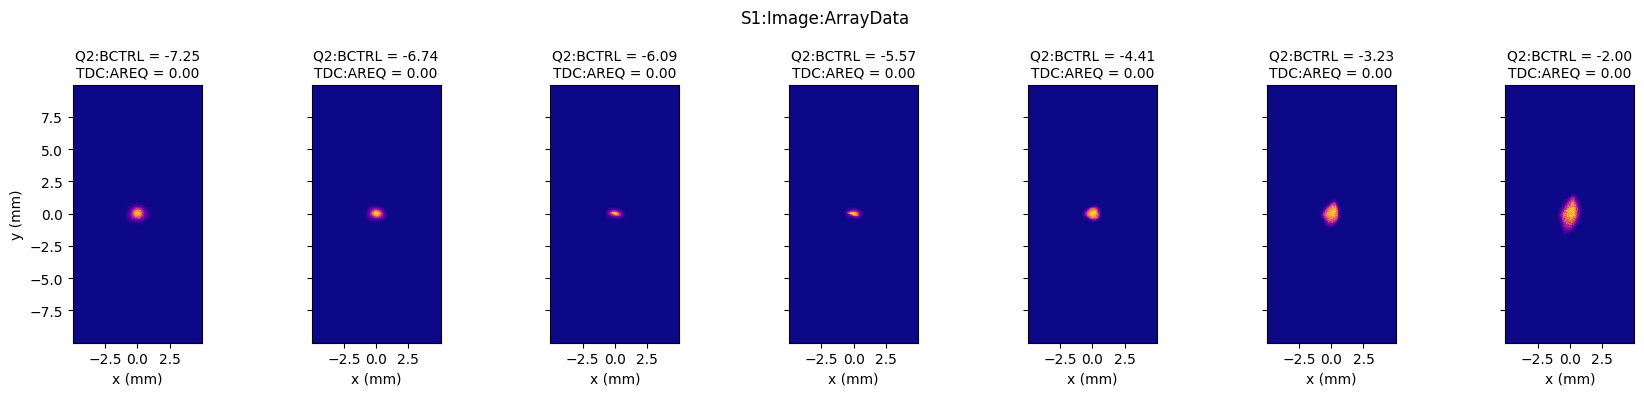

In [7]:
# plot the images from the first quad scan
fig = plot_images(
    beamline_settings=dataset_1.data["beamline_settings"],
    images=dataset_1.data["observations"],
    observations_metadata=dataset_1.observations_metadata,
    pcolormesh_kwargs={"cmap": "plasma"},
    normalize_each=True,
)

In [8]:
# save the GPSRLUMEDataset. It goes to `datasets/`, not back into `measurements/`:
# the raw scan directories are this notebook's input and stay untouched.
dataset_1.save(DATASETS_DIR / "S1_tdc_off.pt")

In [9]:
# inspect the saved file. The saved file is simply a dict with tensors and metadata,
# so it loads with `weights_only=True` -- nothing in it is a pickled object.
dataset_1_saved_file = torch.load(DATASETS_DIR / "S1_tdc_off.pt", weights_only=True)
dataset_1_saved_file

{'format': 'gpsr_lume_dataset',
 'version': 1,
 'dataset': {'beamline_settings': {'Q2:BCTRL': tensor([-7.2525, -6.7354, -6.0889, -5.5717, -4.4120, -3.2283, -2.0000]),
   'TDC:AREQ': tensor([0., 0., 0., 0., 0., 0., 0.])},
  'observations': {'S1:Image:ArrayData': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]],
   
           [[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]],
   
           [[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0.,

In [10]:
# the GPSRLUMEDataset can simply be loaded from the saved file in the future.
dataset_1_loaded = GPSRLUMEDataset.load(DATASETS_DIR / "S1_tdc_off.pt")
dataset_1_loaded

GPSRLUMEDataset(n_samples=7)
  Data: TensorDict(
    fields={
        beamline_settings: TensorDict(
            fields={
                Q2:BCTRL: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
                TDC:AREQ: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([7]),
            device=None,
            is_shared=False),
        observations: TensorDict(
            fields={
                S1:Image:ArrayData: Tensor(shape=torch.Size([7, 200, 400]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([7]),
            device=None,
            is_shared=False)},
    batch_size=torch.Size([7]),
    device=None,
    is_shared=False)
  Observations Metadata: {'S1:Image:ArrayData': {'type': 'screen', 'shape': (200, 400), 'pixel_size': tensor([5.0000e-05, 5.0000e-05])}}
  Beamline Constants: {'Q1:BCTRL': tensor(5.4664), 'Q3:BCTRL': tensor(5.1084), 'Q4

## 2. Create a `GPSRLUMEDataModule` from the 4 quad scans' `GPSRLUMEDataset`

The fit needs the *set*: one beam has to explain all four scans at once. A
`GPSRLUMEDataModule` is that set — a mapping of source name to dataset — so reading the
four scans and collecting them is the whole step, and each **directory name becomes its
source name**. Those names are what the fit, the plots and the checkpoints will call
these scans.

In [11]:
# create and save the GPSRLUMEDataset for all quad scans in the measurements directory.
for scan_dir in sorted(path for path in MEASUREMENTS_DIR.iterdir() if path.is_dir()):
    print(f"{scan_dir.name}/")

    images = np.load(scan_dir / "images.npy")
    quad_strengths = np.load(scan_dir / "quad_strengths.npy")
    metadata = json.loads((scan_dir / "metadata.json").read_text())

    image_pv_name = metadata["image_pv_name"]
    observations = {image_pv_name: torch.tensor(images, **tensor_kwargs)}

    # observations_metadata, keyed by the same image PV names. That key is how the
    # model finds the screen: it looks the PV up in the accelerator's variables and
    # follows it to the Cheetah element, so no screen name is needed here.
    observations_metadata = {
        image_pv_name: {
            "type": "screen",
            "shape": tuple(metadata["screen_shape"]),
            "pixel_size": torch.tensor(metadata["pixel_size"], **tensor_kwargs),
        }
    }

    # beamline settings dict keyed by quad strength and TDC amplitude PV names
    beamline_settings = {
        metadata["quad_pv_name"]: torch.tensor(quad_strengths, **tensor_kwargs),
        metadata["tdc_pv_name"]: torch.full(
            (len(quad_strengths),), metadata["tdc_amplitude"], **tensor_kwargs
        ),
    }

    # what was held fixed for the whole scan, one scalar each
    beamline_constants = {
        pv_name: torch.tensor(value, **tensor_kwargs)
        for pv_name, value in metadata["beamline_constants"].items()
    }

    # Create GPSRLUMEDataset from the quad scan measurement data.
    dataset = GPSRLUMEDataset(
        observations=observations,
        observations_metadata=observations_metadata,
        beamline_settings=beamline_settings,
        beamline_constants=beamline_constants,
    )

    # save the GPSRLUMEDataset, named for the scan it came from.
    dataset.save(DATASETS_DIR / f"{scan_dir.name}.pt")
    print("saved GPSRLUMEDataset to", DATASETS_DIR / f"{scan_dir.name}.pt")

S1_tdc_off/
saved GPSRLUMEDataset to datasets/S1_tdc_off.pt
S1_tdc_on/
saved GPSRLUMEDataset to datasets/S1_tdc_on.pt
S2_tdc_off/
saved GPSRLUMEDataset to datasets/S2_tdc_off.pt
S2_tdc_on/
saved GPSRLUMEDataset to datasets/S2_tdc_on.pt


In [12]:
# load the GPSRLUMEDataset for every scan, keyed by scan name. The names come from
# `measurements/` rather than a glob over `datasets/`, which also holds the datamodule
# written further down -- a glob would try to load that as a dataset on a re-run.
datasets = {}
for scan_dir in sorted(path for path in MEASUREMENTS_DIR.iterdir() if path.is_dir()):
    dataset_path = DATASETS_DIR / f"{scan_dir.name}.pt"
    datasets[scan_dir.name] = GPSRLUMEDataset.load(dataset_path)
    print("loaded GPSRLUMEDataset from", dataset_path)

loaded GPSRLUMEDataset from datasets/S1_tdc_off.pt
loaded GPSRLUMEDataset from datasets/S1_tdc_on.pt
loaded GPSRLUMEDataset from datasets/S2_tdc_off.pt
loaded GPSRLUMEDataset from datasets/S2_tdc_on.pt


In [13]:
# inspect the GPSRLUMEDatasets that were loaded
datasets

{'S1_tdc_off': GPSRLUMEDataset(n_samples=7)
   Data: TensorDict(
     fields={
         beamline_settings: TensorDict(
             fields={
                 Q2:BCTRL: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
                 TDC:AREQ: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False)},
             batch_size=torch.Size([7]),
             device=None,
             is_shared=False),
         observations: TensorDict(
             fields={
                 S1:Image:ArrayData: Tensor(shape=torch.Size([7, 200, 400]), device=cpu, dtype=torch.float32, is_shared=False)},
             batch_size=torch.Size([7]),
             device=None,
             is_shared=False)},
     batch_size=torch.Size([7]),
     device=None,
     is_shared=False)
   Observations Metadata: {'S1:Image:ArrayData': {'type': 'screen', 'shape': (200, 400), 'pixel_size': tensor([5.0000e-05, 5.0000e-05])}}
   Beamline Constants: {'Q1:BCTRL': tensor(5.466

In [14]:
# create a GPSRLUMEDataModule from the dict of GPSRLUMEDatasets.
datamodule = GPSRLUMEDataModule(datasets=datasets)

In [15]:
# inspect the GPSRLUMEDataModule
datamodule

GPSRLUMEDataModule(
  batch_size=full, num_workers=0, pin_memory=False
  sources: ['S1_tdc_off', 'S1_tdc_on', 'S2_tdc_off', 'S2_tdc_on']
  datasets:
    [S1_tdc_off] GPSRLUMEDataset(n_samples=7)
        Data: TensorDict(
          fields={
              beamline_settings: TensorDict(
                  fields={
                      Q2:BCTRL: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
                      TDC:AREQ: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False),
              observations: TensorDict(
                  fields={
                      S1:Image:ArrayData: Tensor(shape=torch.Size([7, 200, 400]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False)},
          batch_size=torch.Size([

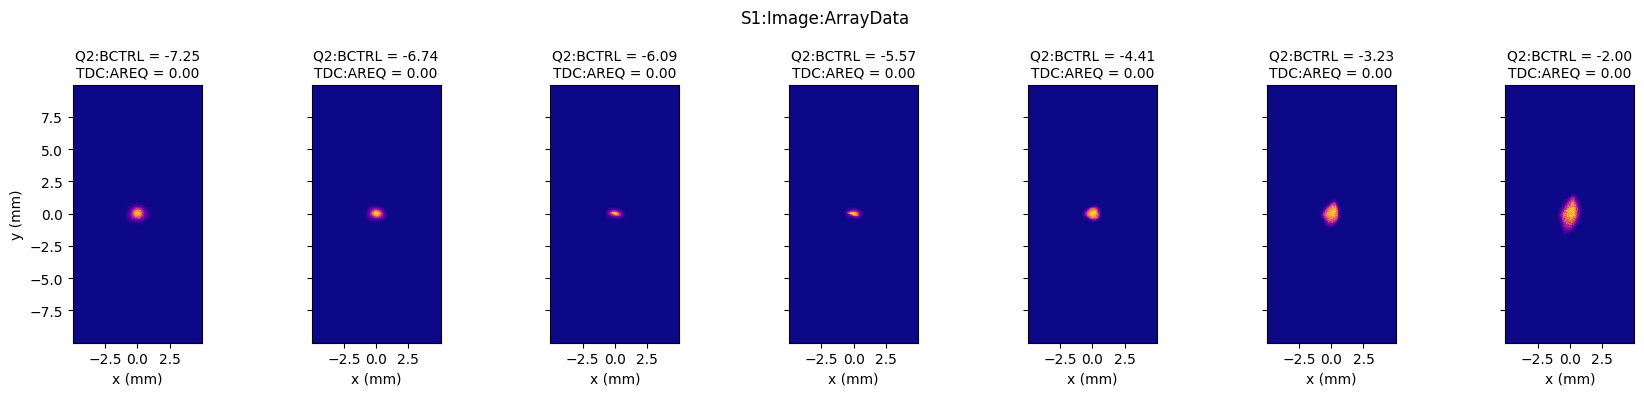

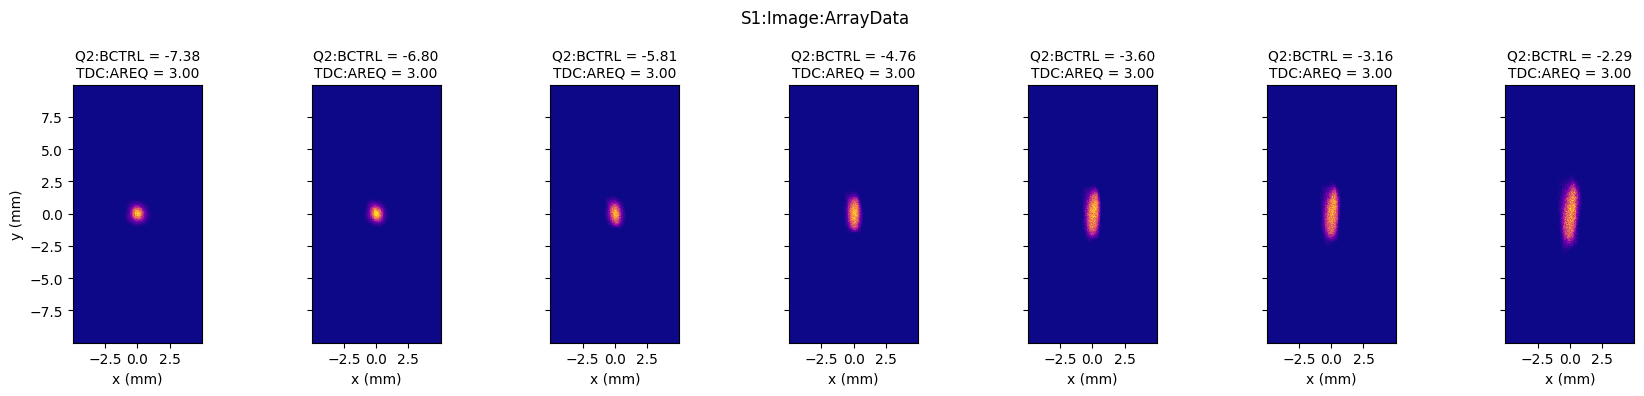

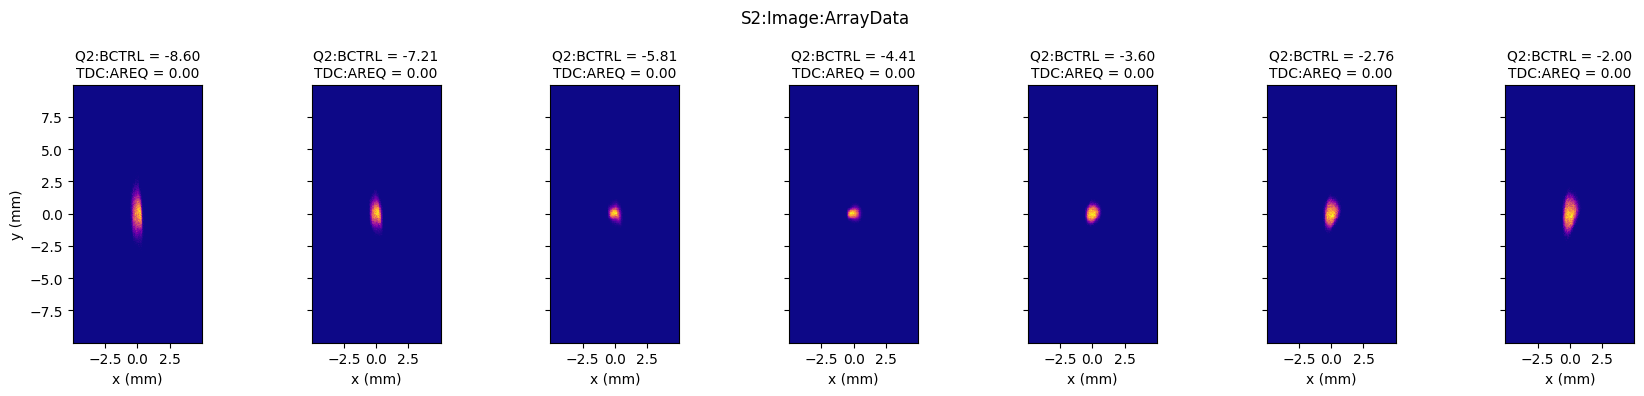

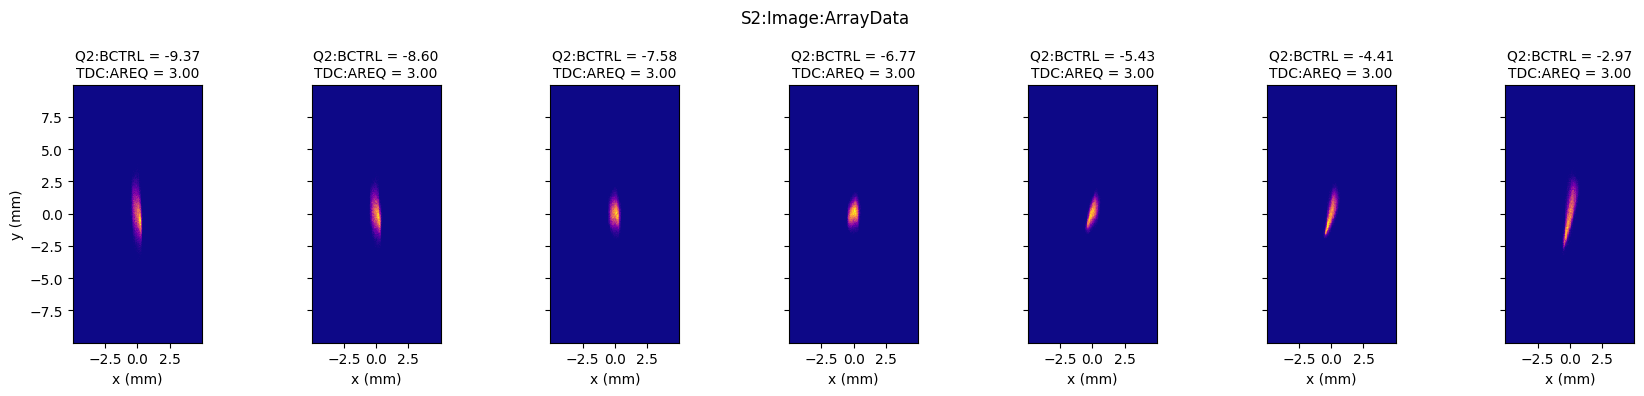

In [16]:
# plot images from all quad scans in the GPSRLUMEDataModule
figures = plot_multi_source_images(
    images=datamodule.to_observations(),
    sources_spec=datamodule.to_sources_spec(),
    pcolormesh_kwargs={"cmap": "plasma"},
    normalize_each=True,
)

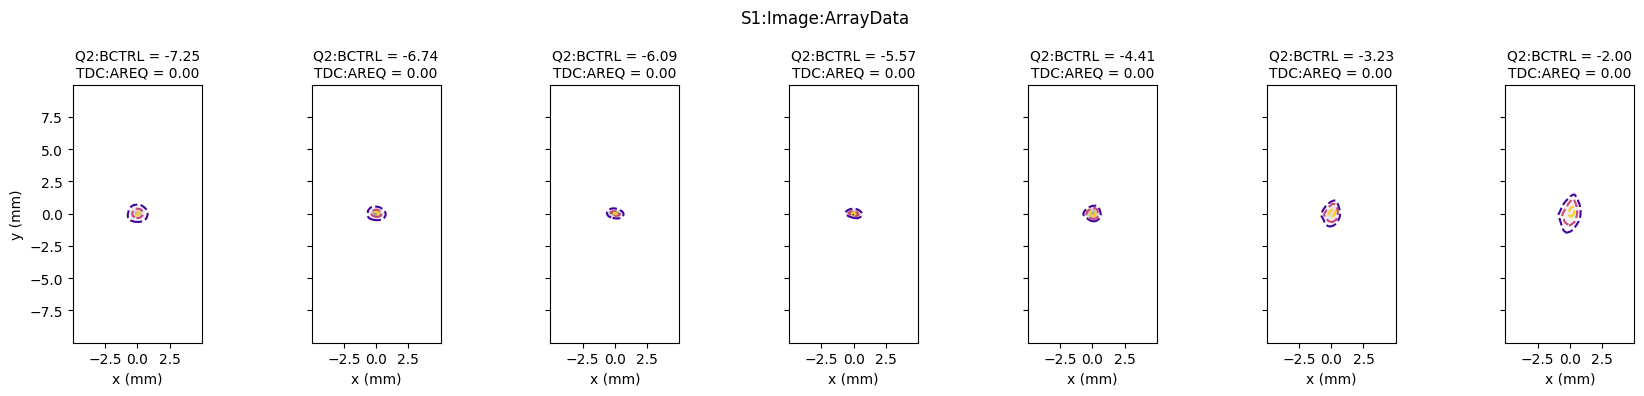

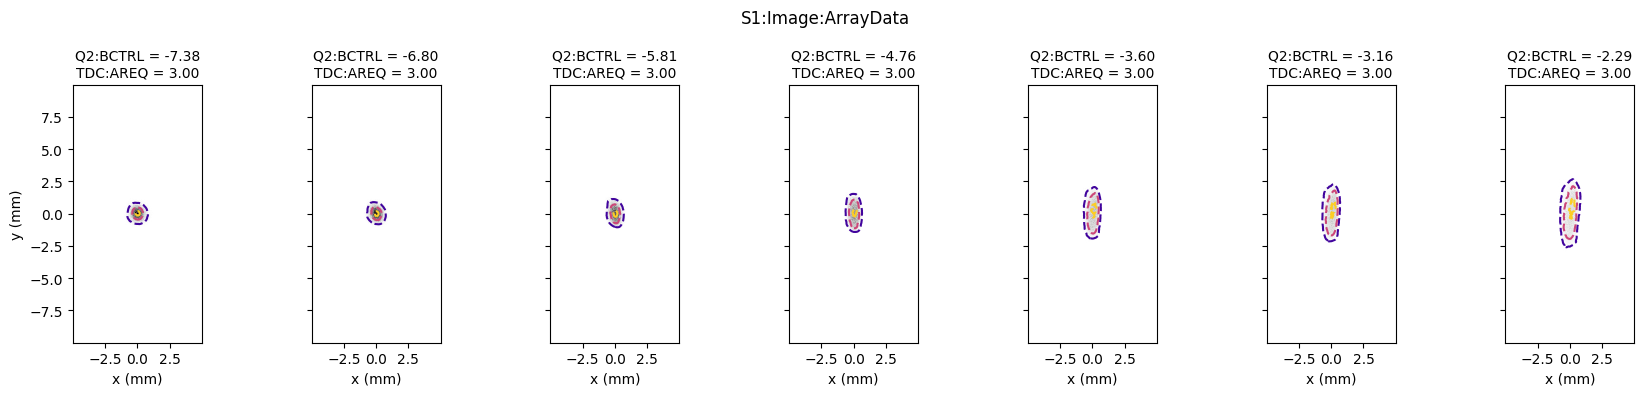

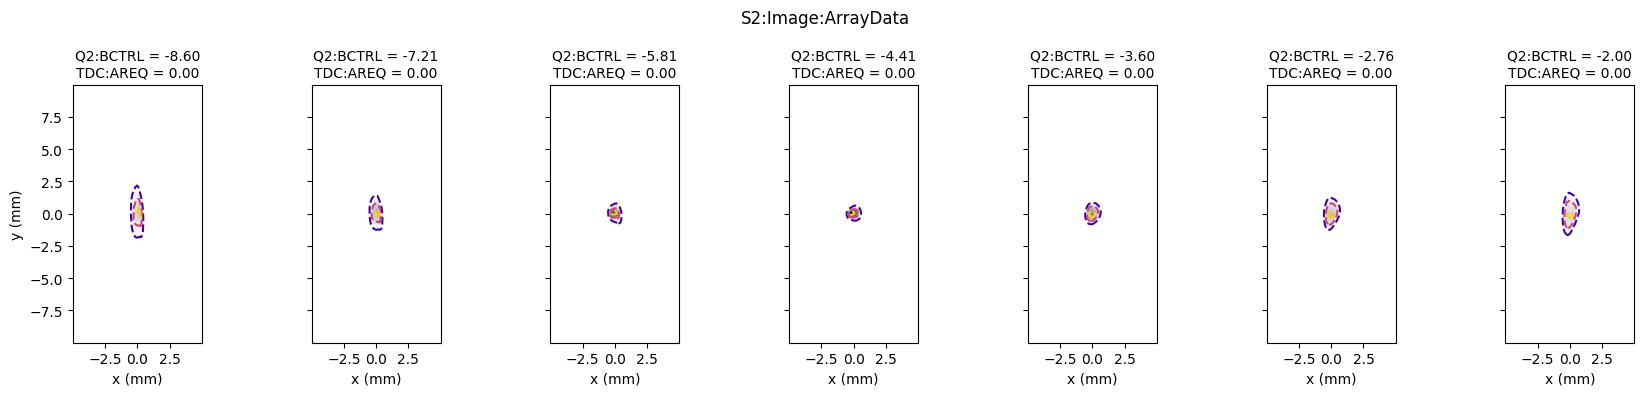

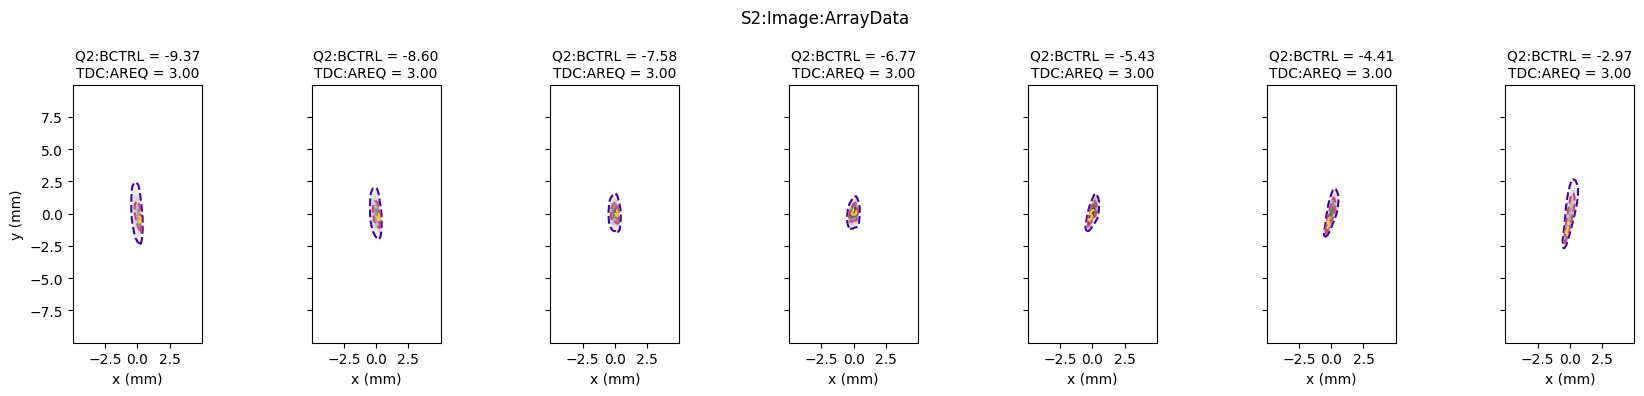

In [17]:
# same, but with contours
figures = plot_multi_source_images(
    images=datamodule.to_observations(),
    sources_spec=datamodule.to_sources_spec(),
    contours=True,
)

In [18]:
# save GPSRLUMEDataModule -- the whole set in one file, source names included. This is
# the file `gpsr_lume_training.ipynb` reads, so run this notebook before that one.
datamodule.save(DATASETS_DIR / "gpsr_lume_datamodule.pt")
print("saved GPSRLUMEDataModule to", DATASETS_DIR / "gpsr_lume_datamodule.pt")

saved GPSRLUMEDataModule to datasets/gpsr_lume_datamodule.pt


In [19]:
# inspect the saved file. The saved file is simply a dict with tensors and metadata.
datamodule_saved_file = torch.load(
    DATASETS_DIR / "gpsr_lume_datamodule.pt", weights_only=True
)
datamodule_saved_file

{'format': 'gpsr_lume_datamodule',
 'version': 1,
 'sources': {'S1_tdc_off': {'beamline_settings': {'Q2:BCTRL': tensor([-7.2525, -6.7354, -6.0889, -5.5717, -4.4120, -3.2283, -2.0000]),
    'TDC:AREQ': tensor([0., 0., 0., 0., 0., 0., 0.])},
   'observations': {'S1:Image:ArrayData': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],
             ...,
             [0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.]],
    
            [[0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],
             ...,
             [0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.]],
    
            [[0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],
             [0., 0., 0.,  ..., 0., 0., 0.],

In [20]:
# the GPSRLUMEDataModule can simply be loaded from the saved file in the future.
datamodule_loaded = GPSRLUMEDataModule.load(DATASETS_DIR / "gpsr_lume_datamodule.pt")
datamodule_loaded

GPSRLUMEDataModule(
  batch_size=full, num_workers=0, pin_memory=False
  sources: ['S1_tdc_off', 'S1_tdc_on', 'S2_tdc_off', 'S2_tdc_on']
  datasets:
    [S1_tdc_off] GPSRLUMEDataset(n_samples=7)
        Data: TensorDict(
          fields={
              beamline_settings: TensorDict(
                  fields={
                      Q2:BCTRL: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
                      TDC:AREQ: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False),
              observations: TensorDict(
                  fields={
                      S1:Image:ArrayData: Tensor(shape=torch.Size([7, 200, 400]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False)},
          batch_size=torch.Size([